In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/superstore.csv", encoding='latin1')
df.head()

In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

In [ ]:
print(df.isnull().sum())

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df[['Order Date']].head()

In [ ]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Weekday'] = df['Order Date'].dt.dayofweek
df[['Order Date','Year','Month','Day','Weekday']].head()

In [ ]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

monthly_sales.head()
monthly_sales.shape

In [ ]:
monthly_sales['Lag_1'] = monthly_sales['Sales'].shift(1)
monthly_sales['Lag_2'] = monthly_sales['Sales'].shift(2)
monthly_sales['Lag_3'] = monthly_sales['Sales'].shift(3)

In [ ]:
monthly_sales = monthly_sales.dropna()
monthly_sales.shape

In [ ]:
monthly_sales['Month'] = monthly_sales['Order Date'].dt.month
monthly_sales['Year'] = monthly_sales['Order Date'].dt.year

In [ ]:
X = monthly_sales[
    [
        'Lag_1',
        'Lag_2',
        'Lag_3',
        'Month',
        'Year'
    ]
]

y = monthly_sales['Sales']

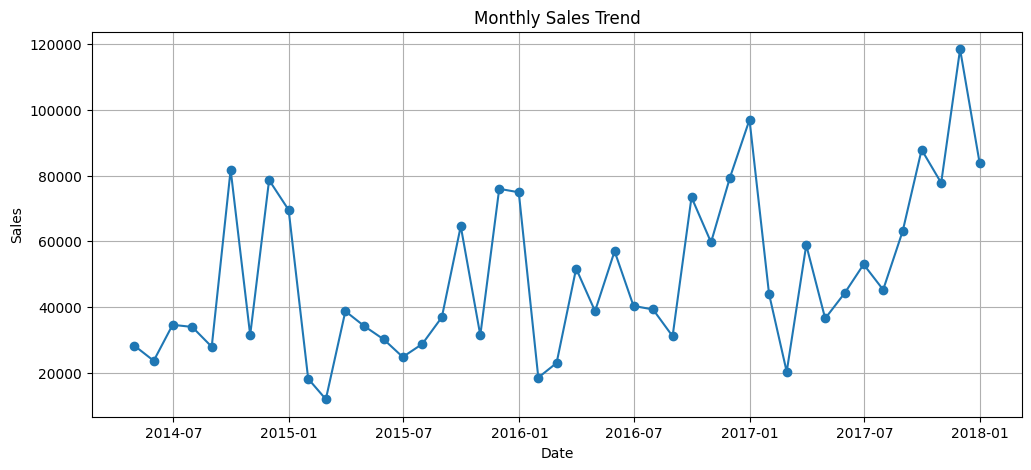

In [21]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales['Order Date'],
    monthly_sales['Sales'],
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

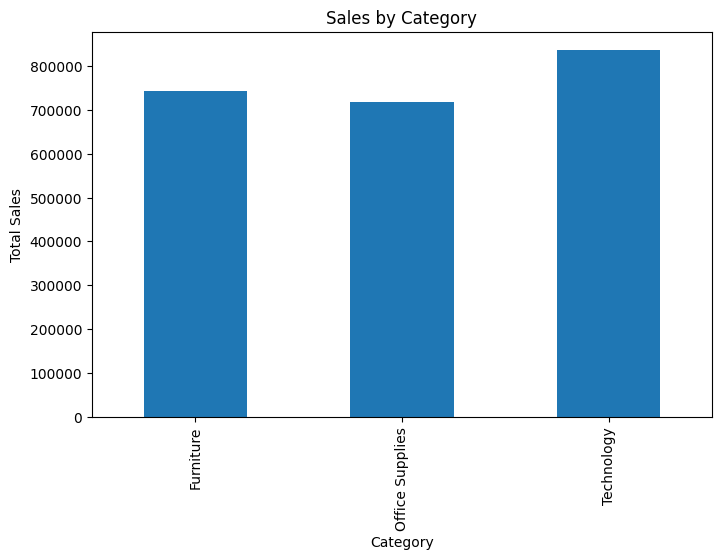

In [22]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

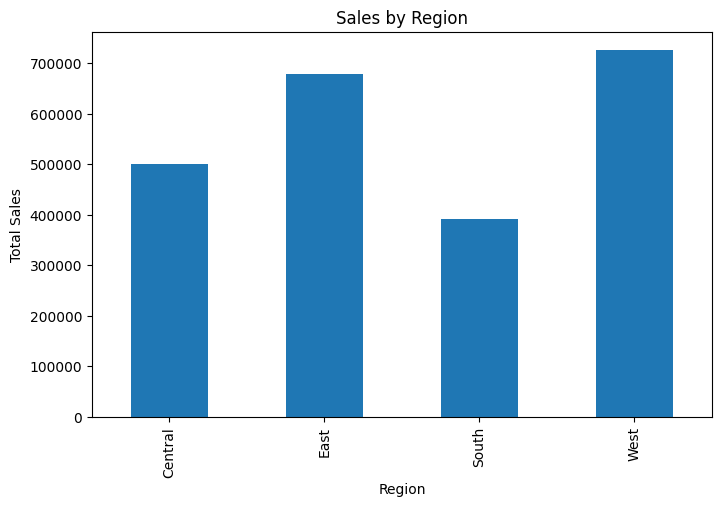

In [23]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

In [ ]:
train_size = int(len(monthly_sales) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [ ]:
print(model)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales['Order Date'][train_size:],
    y_test,
    marker='o',
    label='Actual'
)

plt.plot(
    monthly_sales['Order Date'][train_size:],
    y_pred,
    marker='o',
    label='Predicted'
)

plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
future_predictions = []

last_row = monthly_sales.iloc[-1].copy()

for i in range(3):

    future_date = last_row['Order Date'] + pd.DateOffset(months=1)

    new_row = {
        'Lag_1': last_row['Sales'],
        'Lag_2': last_row['Lag_1'],
        'Lag_3': last_row['Lag_2'],
        'Month': future_date.month,
        'Year': future_date.year
    }

    pred = model.predict(pd.DataFrame([new_row]))[0]

    future_predictions.append({
        'Date': future_date,
        'Forecasted Sales': pred
    })

    last_row['Sales'] = pred
    last_row['Order Date'] = future_date

future_forecast = pd.DataFrame(future_predictions)

future_forecast

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    future_forecast['Date'].dt.strftime('%b-%Y'),
    future_forecast['Forecasted Sales']
)

plt.title("Future Sales Forecast (Next 3 Months)")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")

plt.show()